# Country-Level CO₂ Emissions Forecasting
## Time-Series Machine Learning Project

**Dataset:** Our World in Data CO₂ dataset  
**Target:** `co2`  
**Unit of analysis:** Country-year  
**Country identifier:** `iso_code`  
**Historical period:** 1950 onward

### Project purpose
This notebook develops a country-level time-series forecasting pipeline for annual CO₂ emissions. It follows the **CRISP-DM** methodology and deliberately separates past information from future information to avoid data leakage.

The project asks:

1. **How accurately can historical CO₂ emissions be used to predict future CO₂ emissions for individual countries?**
2. **Which economic, population and energy-related factors are most useful for predicting future CO₂ emissions?**
3. **How do CO₂ emission trends differ across countries over time?**
4. **Can a single forecasting model accurately predict CO₂ emissions across countries using ISO codes and historical characteristics?**
5. **Which time-series modelling approach provides the most accurate CO₂ forecasts?**
6. **How far into the future can CO₂ emissions be forecast with acceptable prediction accuracy?**
7. **Which countries are expected to experience increasing or decreasing CO₂ emissions based on historical trends?**

## 1. Business Understanding

### Why is this project important?

CO₂ emissions are closely connected to energy use, economic activity and population. The **IPCC Sixth Assessment Report** identifies population growth and GDP per capita as important drivers of fossil-fuel CO₂ emissions, while energy intensity and the carbon intensity of energy also affect emissions.

Previous research also demonstrates the value of machine learning for country-level emissions forecasting. **Costantini et al. (2024), Scientific Reports**, developed CO₂ forecasting models for **117 countries** using socioeconomic, energy and economic-complexity indicators and compared modelling approaches including Random Forest.

This project applies the same general forecasting idea to the OWID dataset, while adding explicit time-series features such as lagged emissions and rolling averages.

### Business objective

The aim is to develop an accurate and interpretable model that can forecast future national CO₂ emissions and help identify countries with increasing or decreasing emissions trajectories.

### Success criteria

A successful model should:
- outperform a simple persistence baseline;
- avoid temporal data leakage;
- provide low MAE and RMSE;
- perform reasonably across individual countries;
- identify useful predictors;
- generate future country-level forecasts.

**Research sources:**  
- IPCC AR6 WGIII, Chapter 2: https://www.ipcc.ch/report/ar6/wg3/downloads/report/IPCC_AR6_WGIII_Chapter02.pdf
- Costantini et al. (2024), *Scientific Reports*: https://www.nature.com/articles/s41598-024-73060-0

## 2. Data Understanding

### 2.1. Data Source

The project uses the **Our World in Data (OWID) CO₂ and Greenhouse Gas Emissions Dataset**, which provides comprehensive country-level annual data from 1950 to 2024.

**Dataset characteristics**:
- **Coverage**: 250+ countries and regional aggregates
- **Time span**: 1950-2024 (75 years of historical data)
- **Update frequency**: Regular updates as new data becomes available
- **Format**: CSV with country, year, and multiple emission/socioeconomic indicators

### 2.2. Key Variables for Forecasting

**Target Variable**:
- `co2`: Total CO₂ emissions (in million tonnes)

**Primary Features** (grouped by category):

| Category | Variables | Purpose |
|----------|-----------|---------|
| **Temporal** | `year`, lagged CO₂ values | Capture time trends and momentum |
| **Demographic** | `population`, `population_density` | Control for country size and urbanization |
| **Economic** | `gdp`, `gdp_per_capita` | Proxy for economic activity level |
| **Energy** | `primary_energy_consumption`, `energy_per_capita`, `energy_intensity_level_of_ppp_gdp` | Reflect energy infrastructure and efficiency |
| **Emission Composition** | `coal_co2`, `oil_co2`, `gas_co2`, `cement_co2`, `flaring_co2` | Identify primary emission sources by fuel type |

### 2.3. Data Characteristics

- **Missing values**: Unevenly distributed across countries and time periods (e.g., developing nations have sparse early records)
- **Temporal ordering**: Sequential annual observations; must preserve temporal order in train/test splits
- **Scale variation**: Emissions range from near-zero (small island nations) to billions of tonnes (China, USA); requires normalization/scaling
- **Regional patterns**: Developed nations show stable/declining trends; emerging economies show growth; requires country-level modeling consideration

In [159]:
# Importing the neccesary libraries
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

In [160]:
# Loading the dataset
df_raw = pd.read_csv('owid-co2-data.csv')
df_raw.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
# Checking the shape of the dataset
df_raw.shape

(50411, 79)

This dataset contains **50411** rows and **79** columns

In [162]:
# Checking the datatypes of the columns
df_raw.dtypes

country                                          str
year                                           int64
iso_code                                         str
population                                   float64
gdp                                          float64
cement_co2                                   float64
cement_co2_per_capita                        float64
co2                                          float64
co2_growth_abs                               float64
co2_growth_prct                              float64
co2_including_luc                            float64
co2_including_luc_growth_abs                 float64
co2_including_luc_growth_prct                float64
co2_including_luc_per_capita                 float64
co2_including_luc_per_gdp                    float64
co2_including_luc_per_unit_energy            float64
co2_per_capita                               float64
co2_per_gdp                                  float64
co2_per_unit_energy                          f

Most of the columns in the dataset are numerical (int 64 & float 64) and there are two columns which are string datatype which are country and iso_code.

The year is int 64 instead of datetime so we'll have to change to datetime.

In [163]:
# Checking the information of the dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

It appears that there are missing data in the dataset.

In [164]:
# Checking for missing data (count and percentage)
missing_summary = pd.DataFrame({
    'Missing Count': df_raw.isna().sum(),
    'Missing Percent': df_raw.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,7931,15.73,7931 (15.73%)
population,9244,18.34,9244 (18.34%)
gdp,35160,69.75,35160 (69.75%)
cement_co2,21238,42.13,21238 (42.13%)
cement_co2_per_capita,24763,49.12,24763 (49.12%)
co2,21027,41.71,21027 (41.71%)
co2_growth_abs,23195,46.01,23195 (46.01%)
co2_growth_prct,24172,47.95,24172 (47.95%)


The above are the number of missing data and their percentage of every column in the dataset.

This dataset has alot of missing data some columns even has as far as 90% missing data. We'll have to take a closer look at the data and remove some columns if necessary.

In [165]:
# Checking the feature/column names
df_raw.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

The above is all the names of the columns in this dataset.

In [166]:
# checking the description of the dataset
df_raw.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,23496.000000,23757.000000,16790.000000,10133.000000,26509.000000,17528.000000,10826.000000,21925.000000,21314.000000,5053.000000,4643.000000,4448.000000,29151.000000,2.756300e+04,2.379600e+04,21925.000000,16111.000000,18147.000000,37450.000000,25458.000000,3254.000000,10586.000000,7787.000000,16174.000000,14910.000000,18147.000000,17446.000000,35842.00000,36179.000000,37450.000000,36635.000000,38150.000000,36179.000000,38500.000000,36439.000000,25459.000000,24722.000000,2659.000000,3254.000000,10631.000000,22270.000000,27563.000000,23796.000000,21925.000000,22270.000000,27563.000000,23796.000000,21925.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,4.132343,7.115447,2.328426,1343.224898,3.821411,0.397679,251.177589,185.496070,1.285324,1318.129607,6.463631,0.349924,196.486344,1.249223e+04,2.790247e+04,9311.023979,177.231149,1876.820098,9998.375654,3777.605153,417.861562,24218.017776,1.672906,5.854644,0.270544,74.840369,0.797032,3.07991,7.716833,124.752927,3.905510,95.277707,1.741468,25.424751,0.444591,115.307630,2.192718,0.082205,20.116569,2450.931544,3.002813,5.369860,3.457512,6.791725,2.995657,5.500642,3.321957,6.974350,3.043673,4.104541,2.559362,3.351795,7.053671,3.126383,4.195698,2.439717,3.333339,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,166.964358,8.921137,5.626872,6678.225759,14.312856,0.754065,315.226128,855.418419,2.351089,3904.104954,6.852299,0.247281,1495.918343,7.312143e+04,1.269563e+05,43499.981365,926.732659,11756.922691,46043.141427,24886.829185,1317.317547,32203.518384,1.629769,26.749898,2.995049,397.296985,2.805144,7.78545,11.276765,519.818810,9.106597,434.707032,3.832696,129.896895,0.799286,646.556645,13.948769,0.079726,55.644708,11383.276535,13.389959,18.734892,11.709725,20.969463

Skewed

## 3. Data cleaning

### 3.1. Dropping rows without iso_codes to filter countries

In [167]:
# Dropping row that don't have iso code
df_countries = df_raw[
    df_raw["iso_code"].notna()
]

### 3.2. Getitng the correlation of CO2 with the other columns

In [168]:
# Defining the target as co2
target = 'co2'

correlations = df_countries.select_dtypes(include='number').corr()[target]
print(correlations.sort_values(ascending=False))

co2                                          1.000000
total_ghg_excluding_lucf                     0.998848
consumption_co2                              0.993112
primary_energy_consumption                   0.988604
total_ghg                                    0.953452
co2_including_luc                            0.951048
share_global_other_co2                       0.950661
gdp                                          0.924912
coal_co2                                     0.923477
cumulative_coal_co2                          0.893168
other_industry_co2                           0.889258
share_global_cumulative_other_co2            0.884977
temperature_change_from_ghg                  0.882681
nitrous_oxide                                0.880835
oil_co2                                      0.874346
temperature_change_from_ch4                  0.868975
cumulative_cement_co2                        0.866290
cumulative_co2_including_luc                 0.864406
temperature_change_from_n2o 

### 3.3. Keeping the most correlated columns

In [169]:
# List of the columns to keep
columns_to_keep = ['country', 'year', 'iso_code', 'gdp', 'population', 'co2', 'co2_per_capita', 'flaring_co2', 'cement_co2', 'coal_co2', 'oil_co2', 'gas_co2', 'land_use_change_co2', 'total_ghg', 'other_industry_co2','primary_energy_consumption', 'energy_per_capita','co2_including_luc']

# Keeping relevant columns
df1 = df_countries[columns_to_keep]

### 3.4. Restrict the Historical Period

#### 3.4.1. Checking the missing data by year

In [170]:
# Calculate the overall missing percentage across all other columns per year
missing_pct_by_year = df1.groupby('year').apply(
    lambda x: (x.drop(columns=['year'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['year'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
)
print(missing_pct_by_year)

year
1750    74.509804
1751    80.693816
1752    80.693816
1753    80.693816
1754    80.693816
1755    80.693816
1756    80.693816
1757    80.693816
1758    80.693816
1759    80.693816
1760    74.509804
1761    80.693816
1762    80.693816
1763    80.693816
1764    80.693816
1765    80.693816
1766    80.693816
1767    80.693816
1768    80.693816
1769    80.693816
1770    74.509804
1771    80.693816
1772    80.693816
1773    80.693816
1774    80.693816
1775    80.693816
1776    80.693816
1777    80.693816
1778    80.693816
1779    80.693816
1780    74.509804
1781    80.693816
1782    80.693816
1783    80.693816
1784    80.693816
1785    80.294118
1786    80.294118
1787    80.294118
1788    80.294118
1789    80.294118
1790    73.970588
1791    80.294118
1792    79.913917
1793    79.913917
1794    79.913917
1795    79.913917
1796    79.913917
1797    79.913917
1798    79.913917
1799    79.913917
1800    72.093023
1801    72.366621
1802    71.503268
1803    72.366621
1804    71.925134
1805 

#### Why remove years before 1950?
The project focuses on the modern period in which economic activity, energy systems and emissions data are more relevant to contemporary forecasting. Earlier historical observations also contain substantially more gaps and can make comparisons across countries less consistent.

Therefore, this project uses **1950 onward**.

#### 3.4.2. Removing the years before 1950

In [171]:
# Ensure the 'year' column is of datetime type
df1['year'] = pd.to_datetime(df1['year'], format='%Y').dt.year

# Keep years from 1950 onwards
df1 = df1[df1["year"] >= 1950]

In [172]:
# Checking for missing data of df1
missing_summary = pd.DataFrame({
    'Missing Count': df1.isna().sum(),
    'Missing Percent': df1.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,0,0.00,0 (0.0%)
gdp,4893,29.93,4893 (29.93%)
population,150,0.92,150 (0.92%)
co2,1080,6.61,1080 (6.61%)
co2_per_capita,1163,7.11,1163 (7.11%)
flaring_co2,6697,40.96,6697 (40.96%)
cement_co2,1460,8.93,1460 (8.93%)
coal_co2,5843,35.74,5843 (35.74%)


In [173]:
# get ratio of missing co2 values for each country
missing_co2_by_country = df1.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
missing_co2_by_country.sort_values(ascending=False)

country
San Marino                          1.000000
Monaco                              1.000000
Vatican                             1.000000
East Timor                          0.586667
Eritrea                             0.586667
Marshall Islands                    0.560000
Micronesia (country)                0.560000
Namibia                             0.546667
Anguilla                            0.533333
Andorra                             0.533333
Lesotho                             0.533333
Palestine                           0.533333
Turks and Caicos Islands            0.533333
Tuvalu                              0.533333
Wallis and Futuna                   0.533333
Antarctica                          0.493333
Saint Helena                        0.400000
Christmas Island                    0.400000
Botswana                            0.293333
Maldives                            0.280000
Niue                                0.266667
Bhutan                              0.266667
Co

## 4. data preprocessing
### 4.1. Steps in the preprocessing pipeline

1. Keep only the period we want to model
2. Sort the data chronologically for each country
3. Remove duplicate country-year observations
4. Keep only variables useful for CO2 forecasting
5. Replace infinite values with NaN
6. Remove countries with no CO2 observations

### Data Preprocessing

The preprocessing pipeline prepares the emissions dataset for analysis and forecasting by:

- Filtering observations to the 1950–2024 period.
- Sorting records by country and year to maintain chronological order.
- Removing duplicate **country-year** observations.
- Selecting relevant demographic, economic, energy, CO₂, and greenhouse-gas variables.
- Replacing infinite values (`±∞`) with missing values (`NaN`).
- Removing countries with no available CO₂ observations.
- Returning the resulting cleaned dataset as `df_cleaned`.

This ensures the data is consistent, chronologically organised, and suitable for subsequent exploratory analysis and CO₂ forecasting.

In [174]:
def preprocessing_pipeline(data):

    data = data.copy()

    # 1. Keep only the period we want to model
    data = data[
        (data['year'] >= 1950) &
        (data['year'] <= 2024)
    ].copy()

    # 2. Sort the data chronologically for each country
    data = data.sort_values(
        ['country', 'year']
    ).reset_index(drop=True)

    # 3. Remove duplicate country-year observations
    data = data.drop_duplicates(
        subset=['country', 'year'],
        keep='last'
    )

    # 4. Keep only variables useful for CO2 forecasting
    keep_cols = [
        'country',
        'iso_code',
        'year',
        'population',
        'gdp',
        'co2',
        'co2_per_capita',
        'coal_co2',
        'oil_co2',
        'gas_co2',
        'cement_co2',
        'flaring_co2',
        'land_use_change_co2',
        'primary_energy_consumption',
        'energy_per_capita',
        'energy_per_gdp',
        'total_ghg',
        'total_ghg_excluding_lucf'
    ]

    # Only keep columns that actually exist
    keep_cols = [
        col for col in keep_cols
        if col in data.columns
    ]

    data = data[keep_cols].copy()

    # 5. Replace infinite values with NaN
    data = data.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # 6. Remove countries with no CO2 observations
    country_co2_count = (
        data.groupby('country')['co2']
        .transform('count')
    )

    data = data[
        country_co2_count > 0
    ].copy()

    return data

# Applying the preprocessing pipeline to the dataset
df_cleaned = preprocessing_pipeline(df1)

In [175]:
missing_summary = pd.DataFrame({
    'Missing Count': df_cleaned.isna().sum(),
    'Missing Percentage': (
        df_cleaned.isna().mean() * 100
    )
})

missing_summary = (
    missing_summary
    .sort_values('Missing Percentage', ascending=False)
)

missing_summary

,Missing Count,Missing Percentage
gas_co2,8118,50.344186
flaring_co2,6472,40.136434
energy_per_capita,6261,38.827907
primary_energy_consumption,6216,38.548837
coal_co2,5618,34.840310
gdp,4668,28.948837
land_use_change_co2,1575,9.767442
cement_co2,1235,7.658915
total_ghg,1200,7.441860
oil_co2,957,5.934884


In [176]:
# Getting the information of the cleaned dataset
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 16125 entries, 0 to 16349
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     16125 non-null  str    
 1   iso_code                    16125 non-null  str    
 2   year                        16125 non-null  int32  
 3   population                  15975 non-null  float64
 4   gdp                         11457 non-null  float64
 5   co2                         15270 non-null  float64
 6   co2_per_capita              15187 non-null  float64
 7   coal_co2                    10507 non-null  float64
 8   oil_co2                     15168 non-null  float64
 9   gas_co2                     8007 non-null   float64
 10  cement_co2                  14890 non-null  float64
 11  flaring_co2                 9653 non-null   float64
 12  land_use_change_co2         14550 non-null  float64
 13  primary_energy_consumption  9909 non-null   flo

In [177]:
missing_pct_by_year = df_cleaned.groupby('country')['co2'].apply(
    lambda x: (x.isna().sum() / x.size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
).sort_values(ascending=False)
print(missing_pct_by_year)

country
Eritrea                             58.666667
East Timor                          58.666667
Micronesia (country)                56.000000
Marshall Islands                    56.000000
Namibia                             54.666667
Anguilla                            53.333333
Andorra                             53.333333
Wallis and Futuna                   53.333333
Turks and Caicos Islands            53.333333
Tuvalu                              53.333333
Palestine                           53.333333
Lesotho                             53.333333
Antarctica                          49.333333
Christmas Island                    40.000000
Saint Helena                        40.000000
Botswana                            29.333333
Maldives                            28.000000
Bhutan                              26.666667
Niue                                26.666667
Cook Islands                        25.333333
Oman                                18.666667
Nauru                     

In [178]:
# Remove countries with over 30% missing data in the 'co2' column
missing_co2_by_country = df_cleaned.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
countries_to_remove = missing_co2_by_country[missing_co2_by_country > 0.3].index
df_cleaned = df_cleaned[~df_cleaned['country'].isin(countries_to_remove)]

We have countries that would hinder the modelling phase with too little data so we removed them. 

## 5. Exploratory Data Analysis

### 5.1. CO2 Emmissions over time

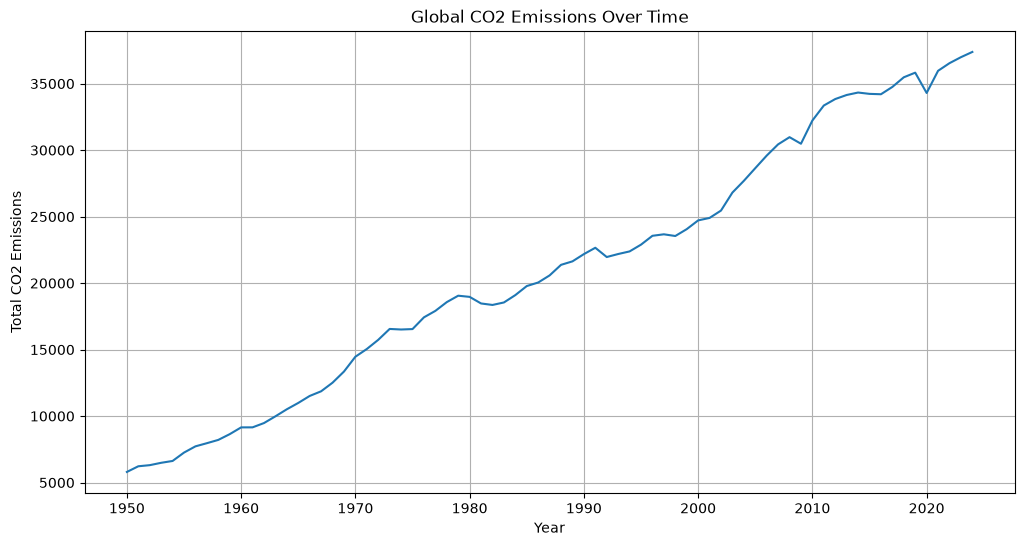

In [179]:
# create a line plot that shows the total co2 emissions over time. i want to show the global emissions.
df_global = df_cleaned.groupby('year')['co2'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(df_global['year'], df_global['co2'])
plt.title('Global CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions')
plt.grid(True)
plt.show()

Global CO₂ emissions show a strong long-term upward trend, rising substantially from 1950 to the most recent years. The main noticeable declines occur around the early 1980s and early 1990s, periods associated with economic slowdowns and reduced energy demand. A sharper decline occurs around 2009 following the global financial crisis, while the largest recent drop is around 2020, largely associated with COVID-19 restrictions that temporarily reduced transportation, industrial activity, and energy use. Emissions rebounded quickly afterward and reached new highs, showing that the overall long-term trend remains upward.

### 5.2. Total CO₂ Emissions per Country

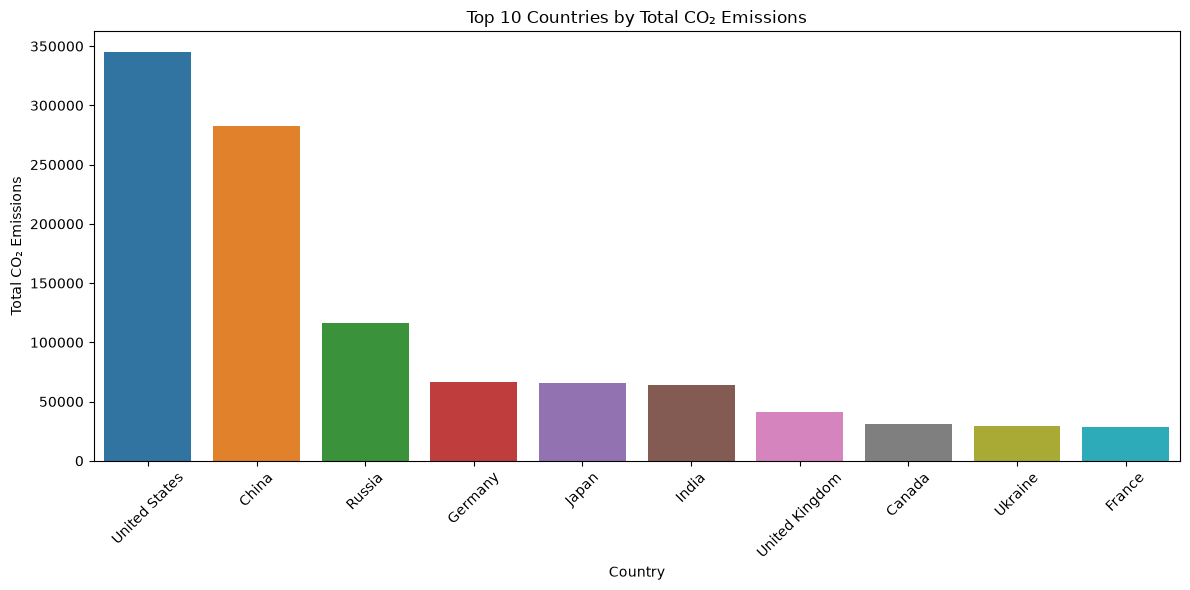

In [180]:
top_emitters = df_cleaned.groupby("country")["co2"].sum().nlargest(10)


# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))


plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The analysis of cumulative CO₂ emissions shows that the **United States is among the largest contributors to total emissions** over the study period. This highlights the significant role of highly industrialized economies in historical global emissions and shows the large differences in emission levels across countries.

### 5.3. CO₂ Emissions Trends of Top 5 Emitting Countries

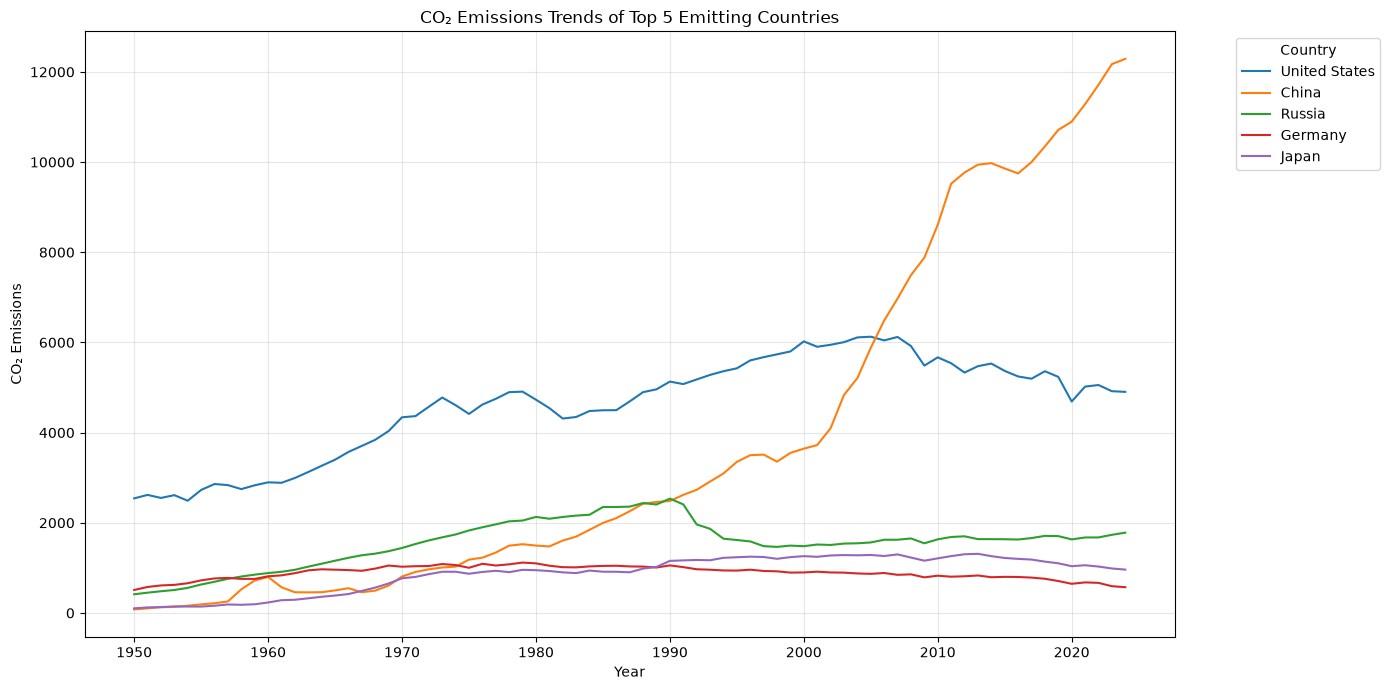

In [181]:
# Identify the top 5 countries by total CO₂ emissions
top_5_countries = top_emitters.head(5).index

top_countries_df = df_cleaned[
    df_cleaned["country"].isin(top_5_countries)
]

plt.figure(figsize=(14, 7))

# Plot each country separately
for country in top_5_countries:
    country_data = top_countries_df[
        top_countries_df["country"] == country
    ].sort_values("year")

    plt.plot(
        country_data["year"],
        country_data["co2"],
        label=country
    )

plt.title("CO₂ Emissions Trends of Top 5 Emitting Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

The CO₂ emissions trend shows different patterns among the major emitting countries. The **United States experienced strong emissions growth historically, but its emissions have remained relatively stable and have declined in more recent years**. This can be associated with slower growth in energy demand, improvements in energy efficiency, a shift away from coal, and increased use of cleaner energy sources.

In contrast, **China's CO₂ emissions increased rapidly, particularly from the early 2000s**. This reflects China's rapid industrialization, economic growth, expansion of manufacturing, urbanization, and heavy dependence on coal for energy.

The comparison shows that CO₂ emissions can change significantly as countries move through different stages of **economic development, industrialization, and energy transition**.

### 5.4. Correlation Between CO₂, Energy and Economic Variables

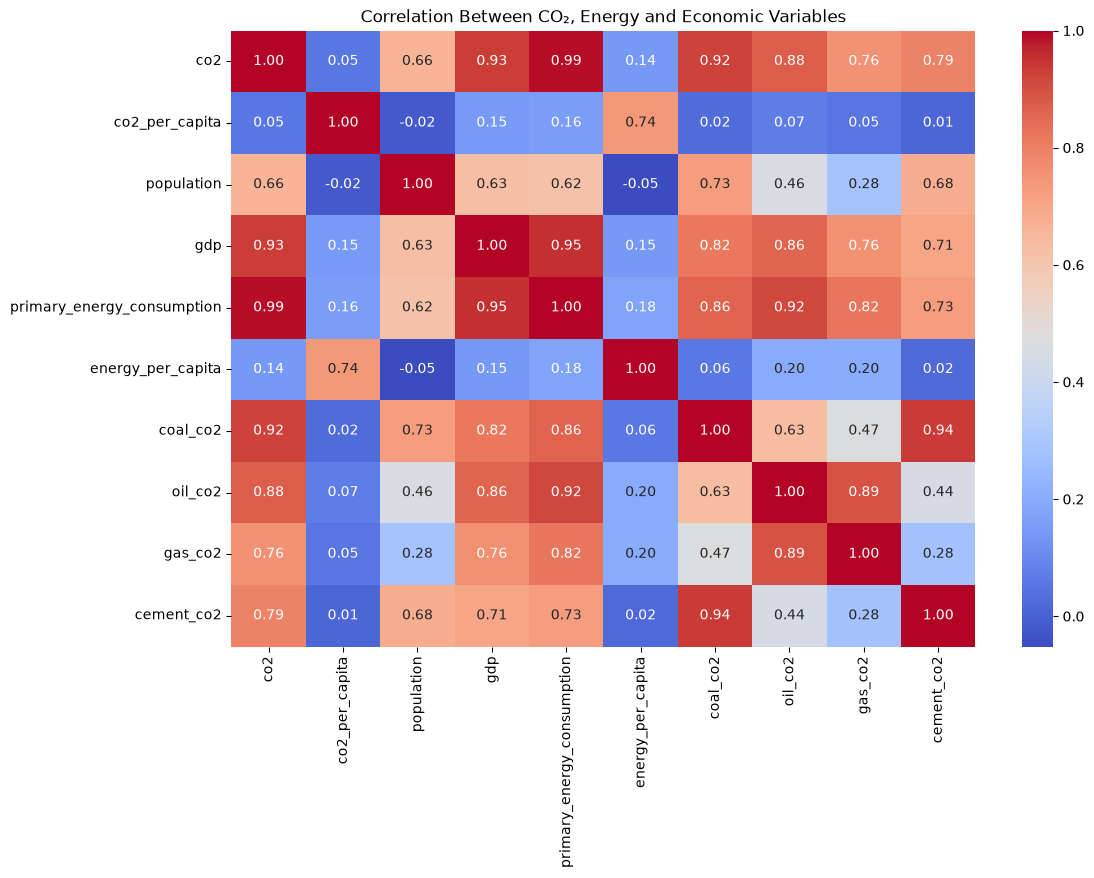

In [182]:
corr_cols = [
    'co2',
    'co2_per_capita',
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'coal_co2',
    'oil_co2',
    'gas_co2',
    'cement_co2'
]

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_cleaned[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between CO₂, Energy and Economic Variables')
plt.show()

The heatmap shows that **CO₂ emissions are strongly correlated with primary energy consumption (0.99) and GDP (0.93)**, suggesting that higher economic activity and energy use are associated with higher emissions.

CO₂ also has strong relationships with **coal (0.92), oil (0.88), and gas emissions (0.76)**. These results support the importance of **economic activity, energy consumption, and historical emission patterns** when developing the forecasting model.

## 6. Feature Engineering

## Feature Engineering for CO₂ Prediction

The `build_model_frame()` function prepares the dataset for a machine learning model that predicts a country's **CO₂ emissions in the following year**.

### Key Steps

1. **Sort the data**
   - Sorts observations by `country` and `year` to ensure that time-based features are created correctly.

2. **Create current-year features**
   - `gdp_per_capita_calc`: GDP divided by population.
   - `energy_per_person_calc`: Primary energy consumption divided by population.

3. **Create CO₂ lag features**
   - `co2_lag1`: CO₂ emissions from the previous year.
   - `co2_lag2`: CO₂ emissions from two years earlier.
   - `co2_lag3`: CO₂ emissions from three years earlier.

4. **Create rolling CO₂ averages**
   - `co2_roll3`: Average CO₂ emissions over the previous three years.
   - `co2_roll5`: Average CO₂ emissions over the previous five years.
   - These capture short-term and longer-term emission trends.

5. **Calculate CO₂ growth**
   - `co2_growth_lag1` measures the percentage change in CO₂ emissions from one year to the next.

6. **Create lagged economic and demographic features**
   - `energy_lag1`: Previous year's energy consumption.
   - `gdp_lag1`: Previous year's GDP.
   - `population_lag1`: Previous year's population.

7. **Create the prediction target**
   - `target_co2` represents the **next year's CO₂ emissions**.
   - For example, information from 2024 is used to predict CO₂ emissions in 2025.

8. **Handle invalid values**
   - Infinite values (`inf` and `-inf`) are replaced with `NaN` to make the data suitable for machine learning.

### Overall Purpose

The function transforms the original dataset into a supervised machine learning dataset where:

**Historical CO₂ + Economic + Energy + Population information → Next Year's CO₂ Emissions**

This allows the model to learn how historical emissions, economic activity, energy consumption, and population changes influence future CO₂ emissions.

In [183]:
def build_model_frame(data):

    df = data.copy()

    #  1. Sort first
    df = df.sort_values(
        ['country', 'year']
    ).reset_index(drop=True)

    # 2. Current-year derived features
    df['gdp_per_capita_calc'] = (
        df['gdp'] / df['population']
    )

    df['energy_per_person_calc'] = (
        df['primary_energy_consumption']
        / df['population']
    )

    # 3. CO2 lag features
    grouped = df.groupby('country')

    # Lagged CO2 by 1, 2, and 3 years back.
    df['co2_lag1'] = (
        grouped['co2'].shift(1)
    )

    df['co2_lag2'] = (
        grouped['co2'].shift(2)
    )

    df['co2_lag3'] = (
        grouped['co2'].shift(3)
    )

    # 4. CO2 rolling averages. 
    # 4.1 Average CO₂ emissions over the previous three years.
    df['co2_roll3'] = (
        grouped['co2']
        .shift(1)
        .rolling(3)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # 4.2 Average CO₂ emissions over the previous five years.
    df['co2_roll5'] = (
        grouped['co2']
        .shift(1)
        .rolling(5)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # 5. CO2 growth
    df['co2_growth_lag1'] = (
        grouped['co2']
        .pct_change(fill_method=None)
    )

    # Lagged energy
    df['energy_lag1'] = (
        grouped['primary_energy_consumption']
        .shift(1)
    )

    # Lagged GDP
    df['gdp_lag1'] = (
        grouped['gdp']
        .shift(1)
    )

    # Lagged population
    df['population_lag1'] = (
        grouped['population']
        .shift(1)
    )

    # Create NEXT YEAR's CO2 as target
    df['target_co2'] = (
        grouped['co2'].shift(-1)
    )

    # Replace infinity
    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return df

In [184]:
model_df = build_model_frame(df_cleaned)

print("Model frame shape:", model_df.shape)

model_df.head()

Model frame shape: (15000, 28)


,country,iso_code,year,population,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,land_use_change_co2,primary_energy_consumption,energy_per_capita,total_ghg,gdp_per_capita_calc,energy_per_person_calc,co2_lag1,co2_lag2,co2_lag3,co2_roll3,co2_roll5,co2_growth_lag1,energy_lag1,gdp_lag1,population_lag1,target_co2
0,Afghanistan,AFG,1950,7776180.0,9.421400e+09,0.084,0.011,0.021,0.063,0.0,0.0,NaN,7.085,NaN,NaN,19.869,1211.571749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.092
1,Afghanistan,AFG,1951,7879343.0,9.692280e+09,0.092,0.012,0.026,0.066,0.0,0.0,NaN,8.000,NaN,NaN,21.069,1230.087331,NaN,0.084,NaN,NaN,NaN,NaN,0.095238,NaN,9.421400e+09,7776180.0,0.092
2,Afghanistan,AFG,1952,7987784.0,1.001732e+10,0.092,0.011,0.032,0.060,0.0,0.0,NaN,8.914,NaN,NaN,22.094,1254.080606,NaN,0.092,0.084,NaN,NaN,NaN,0.000000,NaN,9.692280e+09,7879343.0,0.106
3,Afghanistan,AFG,1953,8096703.0,1.063052e+10,0.106,0.013,0.038,0.068,0.0,0.0,NaN,9.964,NaN,NaN,23.256,1312.944293,NaN,0.092,0.092,0.084,0.089333,NaN,0.152174,NaN,1.001732e+10,7987784.0,0.106
4,Afghanistan,AFG,1954,8207954.0,1.086636e+10,0.106,0.013,0.043,0.064,0.0,0.0,NaN,10.821,NaN,NaN,24.251,1323.881688,NaN,0.106,0.092,0.092,0.096667,NaN,0.000000,NaN,1.063052e+10,8096703.0,0.154


Our processed data has 15000 rows and 28 columns for modelling.

In [185]:
# checking the target
model_df[
    [
        'country',
        'year',
        'co2',
        'co2_lag1',
        'co2_lag2',
        'co2_roll3',
        'target_co2'
    ]
].tail(20)

,country,year,co2,co2_lag1,co2_lag2,co2_roll3,target_co2
14980,Zimbabwe,2005,10.698,9.429,10.610,10.645000,10.365
14981,Zimbabwe,2006,10.365,10.698,9.429,10.245667,9.835
14982,Zimbabwe,2007,9.835,10.365,10.698,10.164000,7.720
14983,Zimbabwe,2008,7.720,9.835,10.365,10.299333,8.250
14984,Zimbabwe,2009,8.250,7.720,9.835,9.306667,8.754
14985,Zimbabwe,2010,8.754,8.250,7.720,8.601667,10.363
14986,Zimbabwe,2011,10.363,8.754,8.250,8.241333,11.257
14987,Zimbabwe,2012,11.257,10.363,8.754,9.122333,11.671
14988,Zimbabwe,2013,11.671,11.257,10.363,10.124667,11.946
14989,Zimbabwe,2014,11.946,11.671,11.257,11.097000,12.017


`target_co2` value for 2024 does not exist and will need to be handled next.

In [186]:
# Removing target that does not exist (i.e., the last year for each country)
model_df = model_df[
    model_df['target_co2'].notna()
].copy()

In [187]:
# Choosing feature columns for the model
feature_cols = [
    'year',
    'population',
    'gdp',

    'co2_lag1',
    'co2_lag2',
    'co2_lag3',
    'co2_roll3',
    'co2_roll5',

    'gdp_lag1',
    'population_lag1',

    'primary_energy_consumption',
    'energy_lag1',
    'energy_per_capita',
    'energy_per_gdp',

    'coal_co2',
    'oil_co2',
    'gas_co2',
    'cement_co2',
    'flaring_co2',
    'land_use_change_co2',

    'total_ghg',
    'total_ghg_excluding_lucf',

    'gdp_per_capita_calc',
    'energy_per_person_calc'
]

feature_cols = [
    col for col in feature_cols
    if col in model_df.columns
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 22
['year', 'population', 'gdp', 'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_roll3', 'co2_roll5', 'gdp_lag1', 'population_lag1', 'primary_energy_consumption', 'energy_lag1', 'energy_per_capita', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'land_use_change_co2', 'total_ghg', 'gdp_per_capita_calc', 'energy_per_person_calc']


In [188]:
# Adding countries
feature_cols = ['country'] + feature_cols

categorical_features = ['country']

numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

Separated categorical features and numeric features 

In [189]:
# Handling missing values in the features
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

The `categorical_transformer` is there as a fail safe for deployment. 

## 7. Modeling

### 7.1 Baseline Model
* Our baseline models will be naive forecasting.
* We'll use this model to predict 2025 CO2 levels based on the previous data.

* Train: years up to 2014
* Validation: 2015–2018
* Test: 2019 onward

Then it defines the target variable and builds a simple baseline model using DummyRegressor(strategy='mean').

This baseline predicts the mean CO2 value for every case. It is used as a benchmark to show whether the more advanced model actually adds value.

The notebook reports baseline MAE, RMSE, and R².

In [190]:
# Chronological train / validation / test split
train_df = model_df[
    model_df['year'] <= 2013
].copy()

valid_df = model_df[
    (model_df['year'] >= 2014) &
    (model_df['year'] <= 2018)
].copy()

test_df = model_df[
    (model_df['year'] >= 2019) &
    (model_df['year'] <= 2023)
].copy()

# 2024 will be used later for forecasting 2025
# Shape of train dataset
print(
    "Train:",
    train_df.shape
)

# Shape of validation dataset
print(
    "Validation:",
    valid_df.shape
)

# Shape of test dataset
print(
    "Test:",
    test_df.shape
)

Train: (12560, 28)
Validation: (1000, 28)
Test: (1000, 28)


In [191]:
# Splitting the data into training, validation, and test sets
X_train = train_df[feature_cols]
y_train = train_df['target_co2']

X_valid = valid_df[feature_cols]
y_valid = valid_df['target_co2']

X_test = test_df[feature_cols]
y_test = test_df['target_co2']

# Checking the shape of the training, validation, and test sets
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (12560, 23)
y_train: (12560,)
X_valid: (1000, 23)
y_valid: (1000,)
X_test: (1000, 23)
y_test: (1000,)


In [192]:
# Model data preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

Missing values handled here.

In [193]:
# Baseline model
baseline_valid_pred = valid_df['co2']

baseline_valid_mae = mean_absolute_error(
    y_valid,
    baseline_valid_pred
)

baseline_valid_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        baseline_valid_pred
    )
)

baseline_valid_r2 = r2_score(
    y_valid,
    baseline_valid_pred
)

print("Naive Baseline - Validation")
print("MAE :", round(baseline_valid_mae, 3))
print("RMSE:", round(baseline_valid_rmse, 3))
print("R²  :", round(baseline_valid_r2, 3))

Naive Baseline - Validation
MAE : 5.469
RMSE: 23.611
R²  : 0.999


Very High R-squared shows possible overfitting. Pending investigation.

## 8. Evaluating the model

### 8.1. Evaluating the baseline model

In [194]:
baseline_test_pred = test_df['co2']

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_pred
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_pred
    )
)

baseline_test_r2 = r2_score(
    y_test,
    baseline_test_pred
)

print("Naive Baseline - Test")
print("--------------------------------")
print("MAE :", round(baseline_test_mae, 3))
print("RMSE:", round(baseline_test_rmse, 3))
print("R²  :", round(baseline_test_r2, 3))

Naive Baseline - Test
--------------------------------
MAE : 7.859
RMSE: 36.559
R²  : 0.998
